In [24]:
import os
import json
import matplotlib.pyplot as plt
from matplotlib import font_manager
font_path = "/usr/share/fonts/truetype/msttcorefonts/Arial.ttf"
font_manager.fontManager.addfont(font_path)
plt.rcParams["font.family"] = "Arial"


168.98242000000002


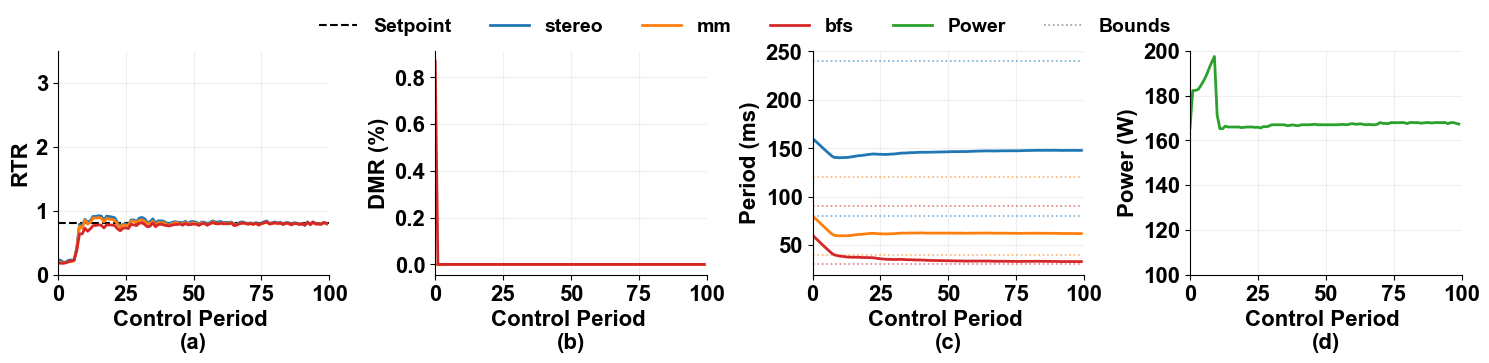

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D

# --------- CONFIG ----------
root = Path("proposed/quasirand_converted_mm_converted_bfs_converted") 
root = Path("proposed/stereodisparity_converted_mm_converted_bfs_converted") 
setpoints = [0.80]
warmup_skip = 0         
max_periods = 100        
save_path = Path("figures")
task_names = ["stereo", "mm", "bfs"]
task_colors = ['tab:blue', 'tab:orange', 'tab:red']

# Styling constants
FIGSIZE = (15, 4) # Slightly taller/wider to prevent overlap
LABEL_FONTSIZE = 16
TICK_FONTSIZE = 16
LINEWIDTH = 2.0
# ---------------------------

def read_data(filepath: Path):
    if not filepath.exists(): return None
    vals = []
    with filepath.open("r") as f:
        for line in f:
            s = line.strip()
            if not s: continue
            try: vals.append(float(s))
            except ValueError: continue
    return vals if vals else None

def slice_idx(data, start, stop):
    if data is None: return None
    n = len(data)
    a = min(max(start, 0), n)
    b = min(max(stop, 0), n)
    return np.asarray(data[a:b], dtype=float)

plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['Arial']})

for sp in setpoints:
    run_dir = root / f"setpoint_{sp:.2f}_{sp:.2f}_{sp:.2f}"
    
    data = {name: {} for name in task_names}
    for i, name in enumerate(task_names, 1):
        t_id = f"t{i}"
        data[name]['rtr'] = slice_idx(read_data(run_dir / f"Proposed_{t_id}_rtr.txt"), warmup_skip, max_periods)
        data[name]['dl']  = slice_idx(read_data(run_dir / f"Proposed_{t_id}_deadline.txt"), warmup_skip, max_periods)
        data[name]['per'] = slice_idx(read_data(run_dir / f"Proposed_{t_id}_period.txt"), warmup_skip, max_periods)
        data[name]['low'] = slice_idx(read_data(run_dir / f"Proposed_{t_id}_lowerperiodbound.txt"), warmup_skip, max_periods)
        data[name]['high']= slice_idx(read_data(run_dir / f"Proposed_{t_id}_higherperiodbound.txt"), warmup_skip, max_periods)

    pwrs = slice_idx(read_data(run_dir / "Proposed_finalpowervalues.txt"), warmup_skip, max_periods)

    fig, axs = plt.subplots(1, 4, figsize=FIGSIZE)

    # (1) RTR
    ax = axs[0]
    ax.axhline(y=sp, color='black', linestyle='--', linewidth=1.5, label="Setpoint")
    for name, color in zip(task_names, task_colors):
        if data[name]['rtr'] is not None:
            ax.plot(data[name]['rtr'], linewidth=LINEWIDTH, label=name, color=color)
    ax.set_ylabel("RTR", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_xlabel("Control Period \n(a)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_ylim(0, 3.5)

    # (2) Deadline
    ax = axs[1]
    for name, color in zip(task_names, task_colors):
        if data[name]['dl'] is not None:
            ax.plot(data[name]['dl'], linewidth=LINEWIDTH, color=color)
    ax.set_ylabel("DMR (%)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_xlabel("Control Period \n(b)", fontsize=LABEL_FONTSIZE, fontweight='bold')

    ax = axs[2]
    for name, color in zip(task_names, task_colors):
        if data[name]['per'] is not None:
            ax.plot(data[name]['per'], linewidth=LINEWIDTH, color=color)
        if data[name]['low'] is not None:
            ax.plot(data[name]['low'], ':', alpha=0.6, linewidth=1.2, color=color)
        if data[name]['high'] is not None:
            ax.plot(data[name]['high'], ':', alpha=0.6, linewidth=1.2, color=color)
    ax.set_ylabel("Period (ms)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_xlabel("Control Period \n(c)", fontsize=LABEL_FONTSIZE, fontweight='bold')

    # (4) Power
    ax = axs[3]
    if pwrs is not None:
        ax.plot(pwrs, linewidth=LINEWIDTH, color='tab:green', label='Power')
    print(np.mean(pwrs))
    ax.set_ylabel("Power (W)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_xlabel("Control Period \n(d)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_ylim([100,200])

    # Global Styling
    for ax in axs:
        ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
        for tick in ax.get_xticklabels(): tick.set_fontweight("bold")
        for tick in ax.get_yticklabels(): tick.set_fontweight("bold")
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(True, alpha=0.2)
        ax.set_xlim([0,100])


    handles, labels = axs[0].get_legend_handles_labels() # Tasks + Setpoint
    power_handle = Line2D([0], [0], color='tab:green', linewidth=LINEWIDTH)
    handles.append(power_handle)
    labels.append("Power")
    bound_handle = Line2D([0], [0], color='gray', linestyle=':', linewidth=1.2, alpha=0.8)
    handles.append(bound_handle)
    labels.append("Bounds")

    fig.legend(
        handles, 
        labels, 
        loc='upper center', 
        bbox_to_anchor=(0.5, 0.92),  
        ncol=len(labels), 
        frameon=False, 
        prop={'weight': 'bold', 'size': 14} 
    )   
    plt.tight_layout(rect=[0, 0, 1, 0.85]) 
    
    save_path.mkdir(exist_ok=True)
    plt.savefig(save_path /'proposed.pdf', bbox_inches='tight')
    plt.show()

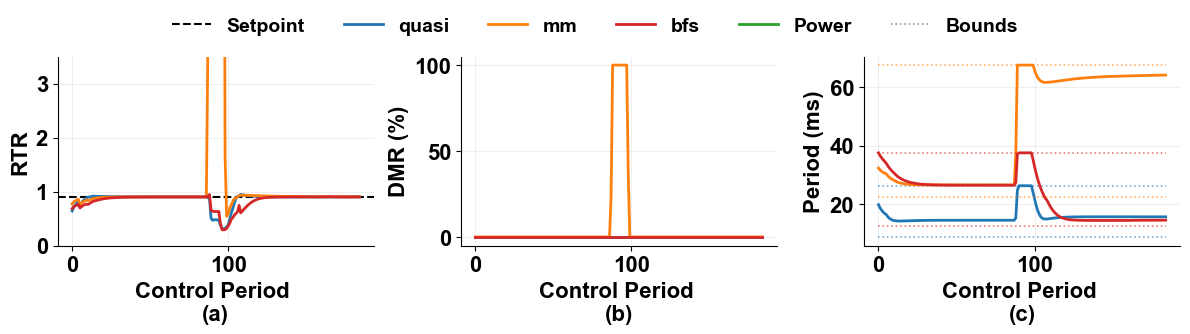

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D

# --------- CONFIG ----------
root = Path("proposed_bounds1/quasirand_converted_mm_interrupt_bfs_converted") 
setpoints = [0.90]
warmup_skip = 10         
max_periods = 400        
save_path = Path("figures")
task_names = ["quasi", "mm", "bfs"]
task_colors = ['tab:blue', 'tab:orange', 'tab:red']

# Styling constants
FIGSIZE = (12, 3.5) 
LABEL_FONTSIZE = 16
TICK_FONTSIZE = 16
LINEWIDTH = 2.0
# ---------------------------

def read_data(filepath: Path):
    if not filepath.exists(): return None
    vals = []
    with filepath.open("r") as f:
        for line in f:
            s = line.strip()
            if not s: continue
            try: vals.append(float(s))
            except ValueError: continue
    return vals if vals else None

def slice_idx(data, start, stop):
    if data is None: return None
    n = len(data)
    a = min(max(start, 0), n)
    b = min(max(stop, 0), n)
    return np.asarray(data[a:b], dtype=float)

plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['Arial']})

for sp in setpoints:
    run_dir = root / f"setpoint_{sp:.2f}_{sp:.2f}_{sp:.2f}"
    
    data = {name: {} for name in task_names}
    for i, name in enumerate(task_names, 1):
        t_id = f"t{i}"
        data[name]['rtr'] = slice_idx(read_data(run_dir / f"Proposed_{t_id}_rtr.txt"), warmup_skip, max_periods)
        data[name]['dl']  = slice_idx(read_data(run_dir / f"Proposed_{t_id}_deadline.txt"), warmup_skip, max_periods)
        data[name]['per'] = slice_idx(read_data(run_dir / f"Proposed_{t_id}_period.txt"), warmup_skip, max_periods)
        data[name]['low'] = slice_idx(read_data(run_dir / f"Proposed_{t_id}_lowerperiodbound.txt"), warmup_skip, max_periods)
        data[name]['high']= slice_idx(read_data(run_dir / f"Proposed_{t_id}_higherperiodbound.txt"), warmup_skip, max_periods)

    pwrs = slice_idx(read_data(run_dir / "Proposed_finalpowervalues.txt"), warmup_skip, max_periods)

    fig, axs = plt.subplots(1, 3, figsize=FIGSIZE)

    # (1) RTR
    ax = axs[0]
    ax.axhline(y=sp, color='black', linestyle='--', linewidth=1.5, label="Setpoint")
    for name, color in zip(task_names, task_colors):
        if data[name]['rtr'] is not None:
            ax.plot(data[name]['rtr'], linewidth=LINEWIDTH, label=name, color=color)
    ax.set_ylabel("RTR", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_xlabel("Control Period \n(a)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_ylim(0, 3.5)

    # (2) Deadline
    ax = axs[1]
    for name, color in zip(task_names, task_colors):
        if data[name]['dl'] is not None:
            ax.plot(data[name]['dl'], linewidth=LINEWIDTH, color=color)
    ax.set_ylabel("DMR (%)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_xlabel("Control Period \n(b)", fontsize=LABEL_FONTSIZE, fontweight='bold')

    ax = axs[2]
    for name, color in zip(task_names, task_colors):
        if data[name]['per'] is not None:
            ax.plot(data[name]['per'], linewidth=LINEWIDTH, color=color)
        if data[name]['low'] is not None:
            ax.plot(data[name]['low'], ':', alpha=0.6, linewidth=1.2, color=color)
        if data[name]['high'] is not None:
            ax.plot(data[name]['high'], ':', alpha=0.6, linewidth=1.2, color=color)
    ax.set_ylabel("Period (ms)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_xlabel("Control Period \n(c)", fontsize=LABEL_FONTSIZE, fontweight='bold')

    # (4) Power
    # ax = axs[3]
    # if pwrs is not None:
    #     ax.plot(pwrs, linewidth=LINEWIDTH, color='tab:green', label='Power')
    # ax.set_ylabel("Power (W)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    # ax.set_xlabel("Control Period \n(d)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    # ax.set_ylim([100,350])

    # Global Styling
    for ax in axs:
        ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
        for tick in ax.get_xticklabels(): tick.set_fontweight("bold")
        for tick in ax.get_yticklabels(): tick.set_fontweight("bold")
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(True, alpha=0.2)
        #ax.set_xlim([0,100])


    handles, labels = axs[0].get_legend_handles_labels() # Tasks + Setpoint
    power_handle = Line2D([0], [0], color='tab:green', linewidth=LINEWIDTH)
    handles.append(power_handle)
    labels.append("Power")
    bound_handle = Line2D([0], [0], color='gray', linestyle=':', linewidth=1.2, alpha=0.8)
    handles.append(bound_handle)
    labels.append("Bounds")

    fig.legend(
        handles, 
        labels, 
        loc='upper center', 
        bbox_to_anchor=(0.5, 0.97),  
        ncol=len(labels), 
        frameon=False, 
        prop={'weight': 'bold', 'size': 14} 
    )   
    plt.tight_layout(rect=[0, 0, 1, 0.85]) 
    
    save_path.mkdir(exist_ok=True)
    plt.savefig(save_path /'proposed1.pdf', bbox_inches='tight')
    plt.show()

Plots generated successfully in the 'figures' folder.


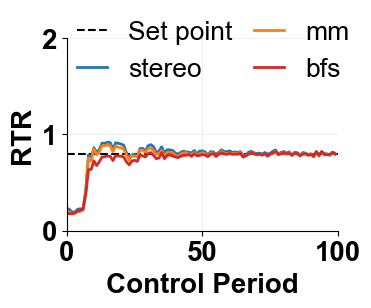

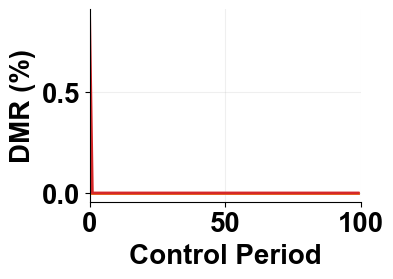

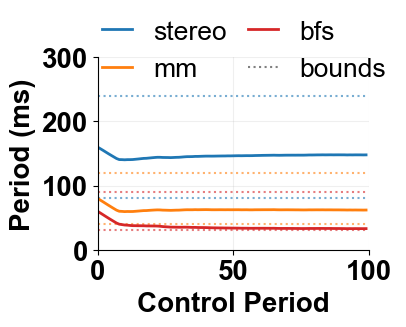

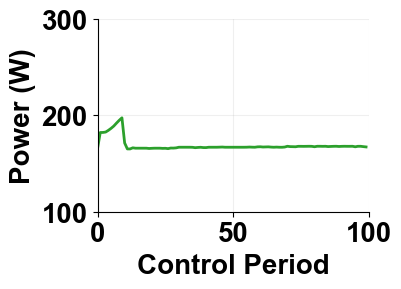

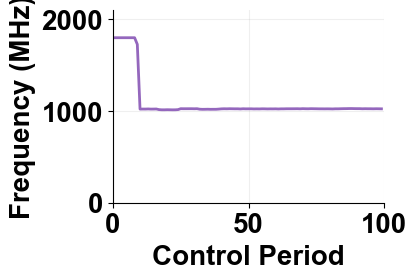

In [95]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D

# --------- CONFIG ----------
root = Path("proposed/stereodisparity_converted_mm_converted_bfs_converted") 
setpoints = [0.80]
warmup_skip = 0         
max_periods = 100        
save_path = Path("figures")
task_names = ["stereo", "mm", "bfs"]
task_colors = ['tab:blue', 'tab:orange', 'tab:red']

# Styling constants for individual plots
FIGSIZE = (3.5, 2.5) 
LABEL_FONTSIZE = 20
TICK_FONTSIZE = 20
LINEWIDTH = 2
# ---------------------------

def read_data(filepath: Path):
    if not filepath.exists(): 
        print(f"Warning: File not found: {filepath}")
        return None
    vals = []
    with filepath.open("r") as f:
        for line in f:
            s = line.strip()
            if not s: continue
            try: vals.append(float(s))
            except ValueError: continue
    return vals if vals else None

def slice_idx(data, start, stop):
    if data is None: return None
    n = len(data)
    a = min(max(start, 0), n)
    b = min(max(stop, 0), n)
    return np.asarray(data[a:b], dtype=float)

def apply_styling(ax):
    """Utility to apply specific styling to an axis."""
    ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
    for tick in ax.get_xticklabels(): tick.set_fontweight("bold")
    for tick in ax.get_yticklabels(): tick.set_fontweight("bold")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.2)
    ax.set_xlim([0, 100])

plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['Arial']})
save_path.mkdir(exist_ok=True)

for sp in setpoints:
    run_dir = root / f"setpoint_{sp:.2f}_{sp:.2f}_{sp:.2f}"
    
    data = {name: {} for name in task_names}
    for i, name in enumerate(task_names, 1):
        t_id = f"t{i}"
        data[name]['rtr'] = slice_idx(read_data(run_dir / f"Proposed_{t_id}_rtr.txt"), warmup_skip, max_periods)
        data[name]['dl']  = slice_idx(read_data(run_dir / f"Proposed_{t_id}_deadline.txt"), warmup_skip, max_periods)
        data[name]['per'] = slice_idx(read_data(run_dir / f"Proposed_{t_id}_period.txt"), warmup_skip, max_periods)
        data[name]['low'] = slice_idx(read_data(run_dir / f"Proposed_{t_id}_lowerperiodbound.txt"), warmup_skip, max_periods)
        data[name]['high']= slice_idx(read_data(run_dir / f"Proposed_{t_id}_higherperiodbound.txt"), warmup_skip, max_periods)

    pwrs = slice_idx(read_data(run_dir / "Proposed_finalpowervalues.txt"), warmup_skip, max_periods)
    
    # FIXED FILENAME HERE:
    freqs = slice_idx(read_data(run_dir / "Proposed_finalfreqvalsvalues.txt"), warmup_skip, max_periods)

    # --- 1. RTR PLOT ---
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.axhline(y=sp, color='black', linestyle='--', linewidth=1.5, label="Set point")
    for name, color in zip(task_names, task_colors):
        if data[name]['rtr'] is not None:
            ax.plot(data[name]['rtr'], linewidth=LINEWIDTH, label=name, color=color)
    ax.set_ylabel("RTR", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_xlabel("Control Period", fontsize=LABEL_FONTSIZE, fontweight='bold')
    apply_styling(ax)
    ax.set_ylim(0,2)
    #ax.legend(frameon=False, prop={'weight': 'bold', 'size': 16}, ncol=2, loc='lower center', bbox_to_anchor=(0.5, 0.95))
    ax.legend(
        frameon=False,          
        fancybox=False,        
        framealpha=0.4,        
        shadow=False,  
        fontsize=19,
        loc='upper center',
        # 0.5 centers it; 1.25 keeps it just above the plot
        bbox_to_anchor=(0.54, 1.15), 
        ncol=2,
        columnspacing=0.8,
        handlelength=1.15,
        borderaxespad=0. 
    )
    plt.savefig(save_path / 'proposed_rtr.pdf', bbox_inches='tight')

    # --- 2. DEADLINE (DMR) PLOT ---
    fig, ax = plt.subplots(figsize=FIGSIZE)
    for name, color in zip(task_names, task_colors):
        if data[name]['dl'] is not None:
            ax.plot(data[name]['dl'], linewidth=LINEWIDTH, color=color, label=name)
    ax.set_ylabel("DMR (%)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_xlabel("Control Period", fontsize=LABEL_FONTSIZE, fontweight='bold')
    apply_styling(ax)
    plt.savefig(save_path / 'proposed_dmr.pdf', bbox_inches='tight')

    # --- 3. PERIOD PLOT ---
    fig, ax = plt.subplots(figsize=FIGSIZE)
    for name, color in zip(task_names, task_colors):
        if data[name]['per'] is not None:
            ax.plot(data[name]['per'], linewidth=LINEWIDTH, color=color, label=name)
        if data[name]['low'] is not None:
            ax.plot(data[name]['low'], ':', alpha=0.6, linewidth=1.5, color=color)
        if data[name]['high'] is not None:
            ax.plot(data[name]['high'], ':', alpha=0.6, linewidth=1.5, color=color)
    ax.set_ylabel("Period (ms)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_xlabel("Control Period", fontsize=LABEL_FONTSIZE, fontweight='bold')
    apply_styling(ax)
    
    bound_handle = Line2D([0], [0], color='gray', linestyle=':', linewidth=1.5)
    handles, labels = ax.get_legend_handles_labels()
    handles.append(bound_handle); labels.append("bounds")
    #ax.legend(handles=handles, labels=labels, frameon=False, prop={'weight': 'bold', 'size': 16}, ncol=2, loc='lower center', bbox_to_anchor=(0.5, 0.95))
    ax.legend(
        handles=handles, 
        labels=labels,
        frameon=False,          
        fancybox=False,        
        framealpha=0.4,        
        shadow=False,  
        fontsize=19,
        loc='upper center',
        # 0.5 centers it; 1.25 keeps it just above the plot
        bbox_to_anchor=(0.54, 1.25), 
        ncol=2,
        columnspacing=0.8,
        handlelength=1.15,
        borderaxespad=0. 
    )
    ax.set_ylim(0,300)
    plt.savefig(save_path / 'proposed_period.pdf', bbox_inches='tight')

    # --- 4. POWER PLOT ---
    fig, ax = plt.subplots(figsize=FIGSIZE)
    if pwrs is not None:
        ax.plot(pwrs, linewidth=LINEWIDTH, color='tab:green')
    ax.set_ylabel("Power (W)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_xlabel("Control Period", fontsize=LABEL_FONTSIZE, fontweight='bold')
    apply_styling(ax)
    ax.set_ylim(100,300)
    plt.savefig(save_path / 'proposed_power.pdf', bbox_inches='tight')

    # --- 5. FREQUENCY PLOT ---
    fig, ax = plt.subplots(figsize=FIGSIZE)
    if freqs is not None:
        ax.plot(freqs, linewidth=LINEWIDTH, color='tab:purple')
    else:
        print("Data for frequency is empty or file missing.")
        
    ax.set_ylabel("Frequency (MHz)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_xlabel("Control Period", fontsize=LABEL_FONTSIZE, fontweight='bold')
    apply_styling(ax)
    ax.relim()
    ax.set_ylim(0,2100)
    ax.autoscale_view()
    plt.savefig(save_path / 'proposed_freq.pdf', bbox_inches='tight')

print("Plots generated successfully in the 'figures' folder.")

Individual plots for proposed1 generated successfully.


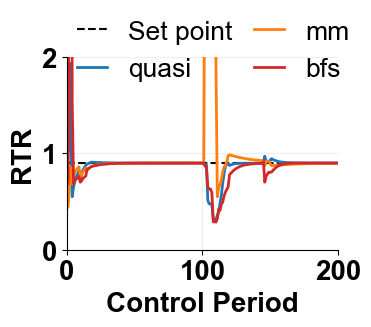

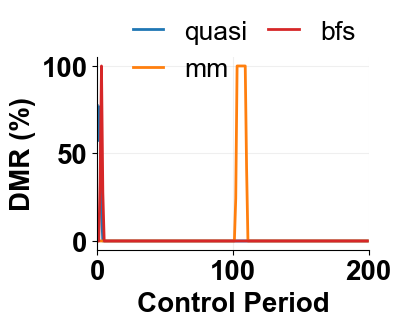

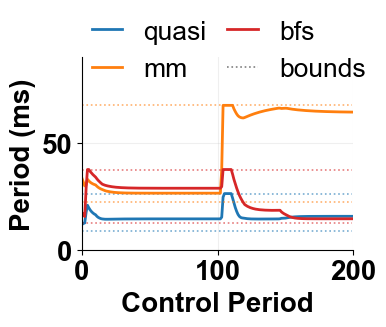

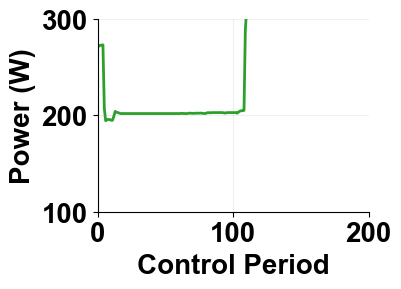

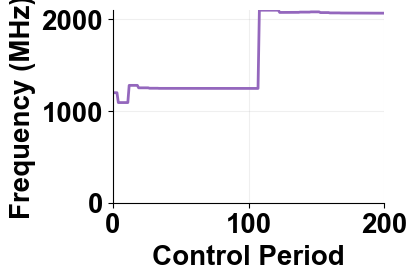

In [93]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D

# --------- CONFIG ----------
root = Path("proposed_bounds1/quasirand_converted_mm_interrupt_bfs_converted") 
setpoints = [0.90]
warmup_skip = 5        
max_periods = 205        
save_path = Path("figures")
task_names = ["quasi", "mm", "bfs"]
task_colors = ['tab:blue', 'tab:orange', 'tab:red']

# Styling constants for individual plots
FIGSIZE = (3.5, 2.5) 
LABEL_FONTSIZE = 20
TICK_FONTSIZE = 20
LINEWIDTH = 2
# ---------------------------

def read_data(filepath: Path):
    if not filepath.exists(): 
        print(f"Warning: File not found: {filepath}")
        return None
    vals = []
    with filepath.open("r") as f:
        for line in f:
            s = line.strip()
            if not s: continue
            try: vals.append(float(s))
            except ValueError: continue
    return vals if vals else None

def slice_idx(data, start, stop):
    if data is None: return None
    n = len(data)
    a = min(max(start, 0), n)
    b = min(max(stop, 0), n)
    return np.asarray(data[a:b], dtype=float)

def apply_styling(ax, data_len):
    """Utility to apply specific styling to an axis."""
    ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
    for tick in ax.get_xticklabels(): tick.set_fontweight("bold")
    for tick in ax.get_yticklabels(): tick.set_fontweight("bold")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.2)
    ax.set_xlim([0, 200])

plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['Arial']})
save_path.mkdir(exist_ok=True)

for sp in setpoints:
    run_dir = root / f"setpoint_{sp:.2f}_{sp:.2f}_{sp:.2f}"
    
    data = {name: {} for name in task_names}
    for i, name in enumerate(task_names, 1):
        t_id = f"t{i}"
        data[name]['rtr'] = slice_idx(read_data(run_dir / f"Proposed_{t_id}_rtr.txt"), warmup_skip, max_periods)
        data[name]['dl']  = slice_idx(read_data(run_dir / f"Proposed_{t_id}_deadline.txt"), warmup_skip, max_periods)
        data[name]['per'] = slice_idx(read_data(run_dir / f"Proposed_{t_id}_period.txt"), warmup_skip, max_periods)
        data[name]['low'] = slice_idx(read_data(run_dir / f"Proposed_{t_id}_lowerperiodbound.txt"), warmup_skip, max_periods)
        data[name]['high']= slice_idx(read_data(run_dir / f"Proposed_{t_id}_higherperiodbound.txt"), warmup_skip, max_periods)

    pwrs = slice_idx(read_data(run_dir / "Proposed_finalpowervalues.txt"), warmup_skip, max_periods)
    freqs = slice_idx(read_data(run_dir / "Proposed_finalfreqvalsvalues.txt"), warmup_skip, max_periods)

    # Determine X-axis limit based on max periods processed
    x_lim = max_periods - warmup_skip

    # --- 1. RTR PLOT ---
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.axhline(y=sp, color='black', linestyle='--', linewidth=1.5, label="Set point")
    for name, color in zip(task_names, task_colors):
        if data[name]['rtr'] is not None:
            ax.plot(data[name]['rtr'], linewidth=LINEWIDTH, label=name, color=color)
    ax.set_ylabel("RTR", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_xlabel("Control Period", fontsize=LABEL_FONTSIZE, fontweight='bold')
    apply_styling(ax, x_lim)
   # ax.legend(frameon=False, prop={'weight': 'bold', 'size': 16}, ncol=2, loc='lower center', bbox_to_anchor=(0.5, 0.95))
    ax.legend(
        frameon=False,          
        fancybox=False,        
        framealpha=0.4,        
        shadow=False,  
        fontsize=19,
        loc='upper center',
        # 0.5 centers it; 1.25 keeps it just above the plot
        bbox_to_anchor=(0.54, 1.25), 
        ncol=2,
        columnspacing=0.8,
        handlelength=1.15,
        borderaxespad=0. 
    )
    ax.set_ylim(0,2)
    plt.savefig(save_path / 'proposed1_rtr.pdf', bbox_inches='tight')

    # --- 2. DEADLINE (DMR) PLOT ---
    fig, ax = plt.subplots(figsize=FIGSIZE)
    for name, color in zip(task_names, task_colors):
        if data[name]['dl'] is not None:
            ax.plot(data[name]['dl'], linewidth=LINEWIDTH,label=name, color=color)
    ax.set_ylabel("DMR (%)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_xlabel("Control Period", fontsize=LABEL_FONTSIZE, fontweight='bold')
    #ax.legend(frameon=False, prop={'weight': 'bold', 'size': 16}, ncol=2, loc='lower center', bbox_to_anchor=(0.5, 0.95))
    ax.legend(
        frameon=False,          
        fancybox=False,        
        framealpha=0.4,        
        shadow=False,  
        fontsize=19,
        loc='upper center',
        # 0.5 centers it; 1.25 keeps it just above the plot
        bbox_to_anchor=(0.54, 1.25), 
        ncol=2,
        columnspacing=0.8,
        handlelength=1.15,
        borderaxespad=0. 
    )
    apply_styling(ax, x_lim)
    plt.savefig(save_path / 'proposed1_dmr.pdf', bbox_inches='tight')

    # --- 3. PERIOD PLOT ---
    fig, ax = plt.subplots(figsize=FIGSIZE)
    for name, color in zip(task_names, task_colors):
        if data[name]['per'] is not None:
            ax.plot(data[name]['per'], linewidth=LINEWIDTH, color=color, label=name)
        if data[name]['low'] is not None:
            ax.plot(data[name]['low'], ':', alpha=0.6, linewidth=1.2, color=color)
        if data[name]['high'] is not None:
            ax.plot(data[name]['high'], ':', alpha=0.6, linewidth=1.2, color=color)
    ax.set_ylabel("Period (ms)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_xlabel("Control Period", fontsize=LABEL_FONTSIZE, fontweight='bold')
    apply_styling(ax, x_lim)
    
    bound_handle = Line2D([0], [0], color='gray', linestyle=':', linewidth=1.2)
    handles, labels = ax.get_legend_handles_labels()
    handles.append(bound_handle); labels.append("bounds")
    #ax.legend(handles=handles, labels=labels, frameon=False, prop={'weight': 'bold', 'size': 16}, ncol=2, loc='lower center', bbox_to_anchor=(0.5, 0.95))
    ax.legend(
        handles=handles, labels=labels,
        frameon=False,          
        fancybox=False,        
        framealpha=0.4,        
        shadow=False,  
        fontsize=19,
        loc='upper center',
        # 0.5 centers it; 1.25 keeps it just above the plot
        bbox_to_anchor=(0.54, 1.25), 
        ncol=2,
        columnspacing=0.8,
        handlelength=1.15,
        borderaxespad=0. 
    )
    
    ax.set_ylim(0,90)
    plt.savefig(save_path / 'proposed1_period.pdf', bbox_inches='tight')

    # --- 4. POWER PLOT ---
    fig, ax = plt.subplots(figsize=FIGSIZE)
    if pwrs is not None:
        ax.plot(pwrs, linewidth=LINEWIDTH, color='tab:green')
    ax.set_ylabel("Power (W)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_xlabel("Control Period", fontsize=LABEL_FONTSIZE, fontweight='bold')
    apply_styling(ax, x_lim)
    ax.set_ylim([100, 300])
    plt.savefig(save_path / 'proposed1_power.pdf', bbox_inches='tight')

    # --- 5. FREQUENCY PLOT ---
    fig, ax = plt.subplots(figsize=FIGSIZE)
    if freqs is not None:
        ax.plot(freqs, linewidth=LINEWIDTH, color='tab:purple')
    ax.set_ylabel("Frequency (MHz)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_xlabel("Control Period", fontsize=LABEL_FONTSIZE, fontweight='bold')
    apply_styling(ax, x_lim)
    ax.set_ylim(0,2100)
    plt.savefig(save_path / 'proposed1_freq.pdf', bbox_inches='tight')

print("Individual plots for proposed1 generated successfully.")